# Task 4 – Substitutions and Goals Scored

## Research Question

Did teams that used more substitutions per match score more goals per match on average in the FIFA World Cup 2026?

## Objective

This analysis investigates whether teams that made more substitutions per match also scored more goals per match during the FIFA World Cup 2026.

## Data Sources

Official team goal totals were obtained from the FIFA World Cup 2026 statistics page. Matches played and substitute appearances were obtained from the FBref 2026 World Cup squad playing-time statistics.

- FIFA World Cup 2026 Statistics
- FBref World Cup 2026 Statistics

In [ ]:
# Importing the libraries needed for data handling, visualisation and statistical analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load and Inspect FBref Playing Time Data

The FBref squad playing-time dataset is used to obtain the number of matches played and total substitute appearances for each team.

In [ ]:
# Loading the FBref playing-time data for the analysis
fbref = pd.read_csv(
    "data/fbref_playing_time.csv",
    header=[0, 1]
)

# Previewing the first few rows of the FBref dataset
fbref.head()

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Playing Time       \
               Squad               # Pl                Age           MP  Min   
0         dz Algeria                 22               27.3            4  360   
1       ar Argentina                 24               29.6            8  810   
2       au Australia                 23               25.3            4  390   
3         at Austria                 20               28.8            4  360   
4         be Belgium                 23               29.2            6  570   

                  Starts                Subs              Team Success      \
  Mn/MP Min%  90s Starts Mn/Start Compl Subs Mn/Sub unSub          PPM onG   
0    90  100  4.0     44       81    25   19     21    37         1.00   5   
1   101  100  9.0     88       87    45   42     30    78         2.63  19   
2    98  100  4.3     44       85    25   19     28    37         1.25   3   
3    90  100  4.0     44       77    24   20     28    40         1.00   6   
4    95  100  6.3     66       81    34   31     28    50         1.83  14   

                  
  onGA +/- +/-90  
0    9  -4 -1.00  
1    8  11  1.22  
2    3   0  0.00  
3    9  -3 -0.75  
4    7   7  1.11

## 2. Extract Required FBref Variables

Only the team name, matches played, and total substitute appearances are required from the FBref dataset.

In [ ]:
# Checking the available column names to identify the required variables
print(fbref.columns.tolist())

[('Unnamed: 0_level_0', 'Squad'), ('Unnamed: 1_level_0', '# Pl'), ('Unnamed: 2_level_0', 'Age'), ('Playing Time', 'MP'), ('Playing Time', 'Min'), ('Playing Time', 'Mn/MP'), ('Playing Time', 'Min%'), ('Playing Time', '90s'), ('Starts', 'Starts'), ('Starts', 'Mn/Start'), ('Starts', 'Compl'), ('Subs', 'Subs'), ('Subs', 'Mn/Sub'), ('Subs', 'unSub'), ('Team Success', 'PPM'), ('Team Success', 'onG'), ('Team Success', 'onGA'), ('Team Success', '+/-'), ('Team Success', '+/-90')]


In [ ]:
# Selecting the team, matches played and substitution columns needed for the analysis
fbref_clean = fbref[
    [
        ('Unnamed: 0_level_0', 'Squad'),
        ('Playing Time', 'MP'),
        ('Subs', 'Subs')
    ]
].copy()

# Renaming the selected columns to make them easier to work with
fbref_clean.columns = [
    'team',
    'matches_played',
    'total_subs'
]

fbref_clean.head()

,team,matches_played,total_subs
0,dz Algeria,4,19
1,ar Argentina,8,42
2,au Australia,4,19
3,at Austria,4,20
4,be Belgium,6,31


In [ ]:
# Cleaning the team names by removing the country codes
fbref_clean['team'] = (
    fbref_clean['team']
    .str.replace(r'^[a-z]{2,3}\s+', '', regex=True)
)

# Checking the cleaned team names
fbref_clean.head()

,team,matches_played,total_subs
0,Algeria,4,19
1,Argentina,8,42
2,Australia,4,19
3,Austria,4,20
4,Belgium,6,31


In [ ]:
# Checking the number of teams available in the FBref dataset
print("Number of teams:", len(fbref_clean))

Number of teams: 48


In [ ]:
# Saving the cleaned FBref data for later use
fbref_clean.to_csv(
    "data/fbref_clean.csv",
    index=False
)

print("Clean FBref data saved.")

Clean FBref data saved.


## 3. Load FIFA Team Goals Data

Official team goal totals were collected from the FIFA World Cup 2026 team statistics page.

In [ ]:
# Loading the team goal data collected from the FIFA statistics
fifa_goals = pd.read_csv("data/fifa_goals.csv")

# Previewing the FIFA goals data
fifa_goals.head()

,team,goals
0,England,20
1,France,20
2,Argentina,19
3,Spain,14
4,Belgium,14


In [ ]:
# Checking the number of teams available in the FIFA dataset
print("Number of FIFA teams:", len(fifa_goals))

Number of FIFA teams: 48


In [ ]:
# Checking the FIFA data for any missing values
print(fifa_goals.isnull().sum())

team     0
goals    0
dtype: int64


In [ ]:
# Comparing the number of teams in both datasets before merging
print("FBref teams:", len(fbref_clean))
print("FIFA teams:", len(fifa_goals))

FBref teams: 48
FIFA teams: 48


In [ ]:
# Comparing the team names to check whether they match across both datasets
fbref_teams = set(fbref_clean["team"])
fifa_teams = set(fifa_goals["team"])

print("Only in FBref:")
print(fbref_teams - fifa_teams)

print()

print("Only in FIFA:")
print(fifa_teams - fbref_teams)

Only in FBref:
set()

Only in FIFA:
set()


## 4. Merge FIFA and FBref Data

The FIFA goals dataset was merged with the FBref matches-played and substitutions dataset using the team name as the common field.

In [ ]:
# Merging the FBref and FIFA datasets using the team names
df = pd.merge(
    fbref_clean,
    fifa_goals,
    on="team",
    how="inner"
)

# Previewing the merged dataset
df.head()

,team,matches_played,total_subs,goals
0,Algeria,4,19,5
1,Argentina,8,42,19
2,Australia,4,19,3
3,Austria,4,20,6
4,Belgium,6,31,14


In [ ]:
# Selecting the main variables needed for the analysis
df = df[
    [
        "team",
        "matches_played",
        "goals",
        "total_subs"
    ]
]

df.head()

,team,matches_played,goals,total_subs
0,Algeria,4,5,19
1,Argentina,8,19,42
2,Australia,4,3,19
3,Austria,4,6,20
4,Belgium,6,14,31


In [ ]:
# Checking the final number of teams and looking for any missing values
print("Final number of teams:", len(df))

print()
print(df.isnull().sum())

Final number of teams: 48

team               0
matches_played     0
goals              0
total_subs         0
goals_per_match    0
subs_per_match     0
subs_group         0
dtype: int64


In [ ]:
# Saving the merged dataset for the main analysis
df.to_csv(
    "data/teams_subs_goals.csv",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


## 5. Inspect the Final Dataset

The merged dataset contains team-level information for matches played, goals scored, and total substitute appearances. The dataset is checked for structure, missing values, and data types before analysis.

In [ ]:
# Previewing the first few rows of the final dataset
df.head()

,team,matches_played,goals,total_subs
0,Algeria,4,5,19
1,Argentina,8,19,42
2,Australia,4,3,19
3,Austria,4,6,20
4,Belgium,6,14,31


In [ ]:
# Checking the structure and data types of the final dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   team            48 non-null     object
 1   matches_played  48 non-null     int64 
 2   goals           48 non-null     int64 
 3   total_subs      48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [ ]:
# Checking again for any missing values in the final dataset
df.isnull().sum()

team              0
matches_played    0
goals             0
total_subs        0
dtype: int64

In [ ]:
# Reviewing the general descriptive statistics of the numerical variables
df.describe()

,matches_played,goals,total_subs
count,48.000000,48.000000,48.000000
mean,4.333333,6.416667,20.833333
std,1.448893,5.164664,7.253270
min,3.000000,0.000000,12.000000
25%,3.000000,2.000000,15.000000
50%,4.000000,5.000000,20.000000
75%,5.000000,10.000000,24.250000
max,8.000000,20.000000,42.000000


## 6. Data Preparation

Goals per match and substitutions per match were calculated so that teams that played different numbers of matches could be compared fairly.

In [ ]:
# Calculating goals per match and substitutions per match for each team
df["goals_per_match"] = (
    df["goals"] / df["matches_played"]
)

df["subs_per_match"] = (
    df["total_subs"] / df["matches_played"]
)

In [ ]:
# Checking the newly calculated per-match values for the first few teams
df[
    [
        "team",
        "matches_played",
        "goals",
        "total_subs",
        "goals_per_match",
        "subs_per_match"
    ]
].head(10)

,team,matches_played,goals,total_subs,goals_per_match,subs_per_match
0,Algeria,4,5,19,1.250000,4.750000
1,Argentina,8,19,42,2.375000,5.250000
2,Australia,4,3,19,0.750000,4.750000
3,Austria,4,6,20,1.500000,5.000000
4,Belgium,6,14,31,2.333333,5.166667
5,Bosnia–Herz,4,5,20,1.250000,5.000000
6,Brazil,5,10,23,2.000000,4.600000
7,Cabo Verde,4,4,21,1.000000,5.250000
8,Canada,5,9,25,1.800000,5.000000
9,Colombia,5,5,22,1.000000,4.400000


In [ ]:
# Rounding the per-match values to make the results easier to read
df[
    [
        "team",
        "goals_per_match",
        "subs_per_match"
    ]
].round(2).head(10)

,team,goals_per_match,subs_per_match
0,Algeria,1.25,4.75
1,Argentina,2.38,5.25
2,Australia,0.75,4.75
3,Austria,1.50,5.00
4,Belgium,2.33,5.17
5,Bosnia–Herz,1.25,5.00
6,Brazil,2.00,4.60
7,Cabo Verde,1.00,5.25
8,Canada,1.80,5.00
9,Colombia,1.00,4.40


## 7. Create High- and Low-Substitution Groups

Teams were divided into high- and low-substitution groups using the median number of substitutions per match.

In [ ]:
# Calculating the median number of substitutions per match
median_subs = df["subs_per_match"].median()

print(
    "Median substitutions per match:",
    round(median_subs, 2)
)

Median substitutions per match: 5.0


In [ ]:
# Dividing the teams into High and Low substitution groups using the median
df["subs_group"] = np.where(
    df["subs_per_match"] > median_subs,
    "High",
    "Low"
)

In [ ]:
# Checking which substitution group each team is being placed into
df[
    [
        "team",
        "subs_per_match",
        "subs_group"
    ]
].round(2)

,team,subs_per_match,subs_group
0,Algeria,4.75,Low
1,Argentina,5.25,High
2,Australia,4.75,Low
3,Austria,5.00,Low
4,Belgium,5.17,High
5,Bosnia–Herz,5.00,Low
6,Brazil,4.60,Low
7,Cabo Verde,5.25,High
8,Canada,5.00,Low
9,Colombia,4.40,Low


In [ ]:
# Counting the number of teams in each substitution group
print(df["subs_group"].value_counts())

subs_group
Low     41
High     7
Name: count, dtype: int64


In [ ]:
# Checking that the two groups are accounting for all 48 teams
print("Total teams:", len(df))
print("High-substitution teams:", (df["subs_group"] == "High").sum())
print("Low-substitution teams:", (df["subs_group"] == "Low").sum())

Total teams: 48
High-substitution teams: 7
Low-substitution teams: 41


In [ ]:
# Separating the goals-per-match values for the High and Low substitution groups
high_subs = df[
    df["subs_group"] == "High"
]["goals_per_match"]

low_subs = df[
    df["subs_group"] == "Low"
]["goals_per_match"]

In [ ]:
# Checking the number of teams included in each group
print("High-substitution teams:", len(high_subs))
print("Low-substitution teams:", len(low_subs))

High-substitution teams: 7
Low-substitution teams: 41


In [ ]:
# Previewing some goals-per-match values from both groups
print("High-substitution goals-per-match values:")
print(high_subs.head())

print()

print("Low-substitution goals-per-match values:")
print(low_subs.head())

High-substitution goals-per-match values:
1     2.375000
4     2.333333
7     1.000000
19    2.750000
29    2.750000
Name: goals_per_match, dtype: float64

Low-substitution goals-per-match values:
0    1.25
2    0.75
3    1.50
5    1.25
6    2.00
Name: goals_per_match, dtype: float64


## 8. Descriptive Statistics

The mean goals per match, standard deviation, and number of teams were calculated for the high- and low-substitution groups to compare their scoring performance.

In [ ]:
# Comparing the mean goals per match and standard deviation between the two groups
print("HIGH-SUBSTITUTION TEAMS")
print("Mean goals per match:", round(high_subs.mean(), 3))
print("Standard deviation:", round(high_subs.std(), 3))
print("Number of teams:", len(high_subs))

print()

print("LOW-SUBSTITUTION TEAMS")
print("Mean goals per match:", round(low_subs.mean(), 3))
print("Standard deviation:", round(low_subs.std(), 3))
print("Number of teams:", len(low_subs))

HIGH-SUBSTITUTION TEAMS
Mean goals per match: 2.196
Standard deviation: 0.641
Number of teams: 7

LOW-SUBSTITUTION TEAMS
Mean goals per match: 1.172
Standard deviation: 0.658
Number of teams: 41


In [ ]:
# Creating a summary table for the descriptive statistics of both groups
summary = df.groupby(
    "subs_group"
)["goals_per_match"].agg(
    ["count", "mean", "std"]
)

summary.round(3)

,count,mean,std
subs_group,,,
High,7,2.196,0.641
Low,41,1.172,0.658


## 9. Visualisation

A boxplot was created to compare the distribution of goals per match between high- and low-substitution teams.

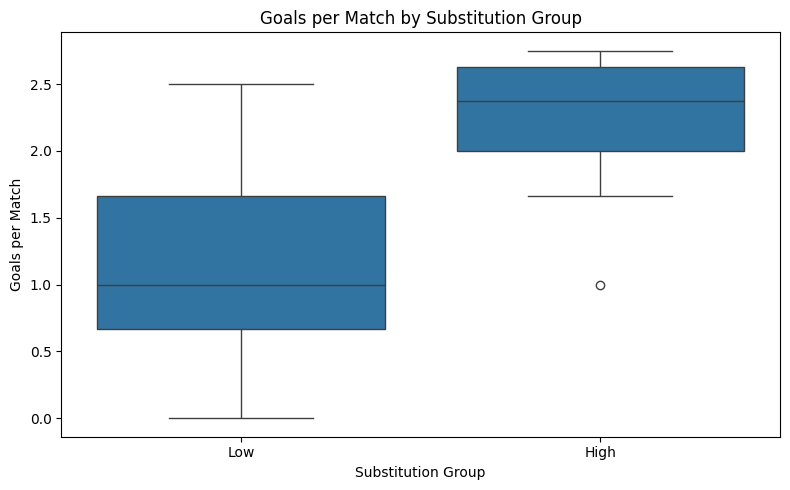

In [ ]:
# Creating a boxplot to compare goals per match between the two substitution groups
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="subs_group",
    y="goals_per_match"
)

plt.title("Goals per Match by Substitution Group")
plt.xlabel("Substitution Group")
plt.ylabel("Goals per Match")

plt.tight_layout()

# Saving the boxplot for use in the presentation
plt.savefig(
    "goals_by_substitution_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Substitutions per Match and Goals per Match

A scatter plot was used to examine the relationship between substitutions per match and goals per match across all teams.

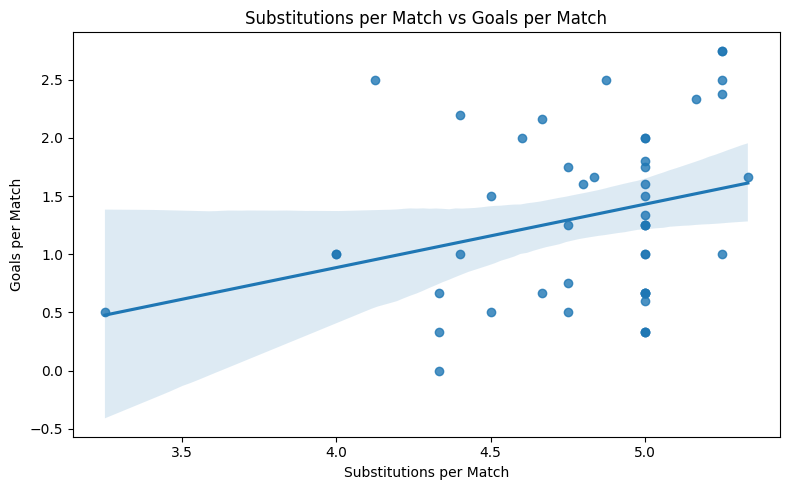

In [ ]:
# Creating a scatter plot to examine the relationship between substitutions and goals per match
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="subs_per_match",
    y="goals_per_match"
)

plt.title("Substitutions per Match vs Goals per Match")
plt.xlabel("Substitutions per Match")
plt.ylabel("Goals per Match")

plt.tight_layout()

# Saving the scatter plot for use in the presentation
plt.savefig(
    "subs_vs_goals_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Confidence Interval

A 95% confidence interval was calculated for the mean goals per match of the high-substitution teams.

In [ ]:
# Calculating the 95% confidence interval for the mean goals per match of the high-substitution teams
n = len(high_subs)
mean = high_subs.mean()
std = high_subs.std()

t_crit = stats.t.ppf(0.975, df=n - 1)

margin = t_crit * std / np.sqrt(n)

ci_lower = mean - margin
ci_upper = mean + margin

print("Mean goals per match for high-substitution teams:", round(mean, 3))
print("95% confidence interval:", (round(ci_lower, 3), round(ci_upper, 3)))

Mean goals per match for high-substitution teams: 2.196
95% confidence interval: (1.603, 2.79)


## 11. Independent-Samples t-Test

An independent-samples t-test was conducted to determine whether the mean goals per match differed significantly between high- and low-substitution teams.

In [ ]:
# Running an independent-samples t-test to compare the scoring averages of the two groups
t_stat, p_val = stats.ttest_ind(
    high_subs,
    low_subs
)

print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_val, 4))

t-statistic: 3.822
p-value: 0.0004


### t-Test Interpretation

The independent-samples t-test produced a t-statistic of 3.822 and a p-value of 0.0004. Since the p-value is below the 0.05 significance level, there is a statistically significant difference in mean goals per match between the high- and low-substitution groups.

The results indicate that teams in the high-substitution group scored more goals per match on average than teams in the low-substitution group. However, this represents an association and does not establish that using more substitutions causes teams to score more goals.

## 12. Correlation Analysis

Pearson correlation was calculated to examine the relationship between substitutions per match and goals per match across all teams.

In [ ]:
# Calculating the Pearson correlation between substitutions per match and goals per match
r, p_corr = stats.pearsonr(
    df["subs_per_match"],
    df["goals_per_match"]
)

print("Pearson correlation coefficient:", round(r, 3))
print("Correlation p-value:", round(p_corr, 4))

Pearson correlation coefficient: 0.295
Correlation p-value: 0.042


### Correlation Interpretation

The Pearson correlation coefficient was 0.295 with a p-value of 0.042. This indicates a weak positive relationship between substitutions per match and goals per match. Since the p-value is below 0.05, the relationship is statistically significant at the 5% significance level.

This suggests that teams making more substitutions per match tended to score more goals per match. However, the correlation is relatively weak and does not demonstrate that making more substitutions directly caused teams to score more goals.

## 13. Results and Interpretation

Teams were divided into high- and low-substitution groups using the median substitution rate of 5.0 substitutions per match. Seven teams were classified as high-substitution teams, while 41 teams were classified as low-substitution teams.

High-substitution teams scored an average of 2.196 goals per match (SD = 0.641), compared with 1.172 goals per match (SD = 0.658) for low-substitution teams. The 95% confidence interval for the mean goals per match of the high-substitution group was 1.603 to 2.790.

The independent-samples t-test found a statistically significant difference in mean goals per match between the two groups (t = 3.822, p = 0.0004). Therefore, high-substitution teams scored significantly more goals per match on average than low-substitution teams in this dataset.

The Pearson correlation between substitutions per match and goals per match was positive but weak (r = 0.295, p = 0.042). This suggests that teams making more substitutions per match tended to score more goals per match, although the overall relationship was not strong.

These results indicate an association between substitution use and scoring performance, but they do not demonstrate that making more substitutions directly causes teams to score more goals.

## 14. Conclusion

The analysis found that teams in the high-substitution group scored more goals per match on average than teams in the low-substitution group. The independent-samples t-test showed that this difference was statistically significant (t = 3.822, p = 0.0004).

The Pearson correlation analysis also found a weak positive and statistically significant relationship between substitutions per match and goals per match (r = 0.295, p = 0.042).

Overall, the results suggest that teams that used more substitutions per match tended to score more goals per match during the FIFA World Cup 2026. However, these findings show an association rather than a causal relationship.

## 15. Limitations

Several factors may influence the observed relationship between substitutions and goals. Stronger teams may both score more goals and use substitutions differently from weaker teams. Teams that progressed further in the tournament also played more matches and faced different opponents and match situations.

Substitutions may also be made for tactical, injury, fatigue, or time-management reasons, so the number of substitutions alone does not explain why goals were scored. Therefore, the results should be interpreted as an association between substitution use and scoring rather than evidence that additional substitutions cause teams to score more goals.